In [52]:
import pandas as pd
import numpy as np
from preprocess import add_outcome

In [53]:
df = pd.read_parquet("all_events_subset.parquet")
df['time'] = pd.to_timedelta(df['matchTimestamp']).dt.total_seconds()
df = df.sort_values(['matchId', 'matchPeriod', 'time']).reset_index(drop=True)
df = add_outcome(df)

In [54]:
PITCH_LENGTH = 120.0
PITCH_WIDTH = 80.0
WINDOW_SEC = 30


def add_speed_of_play_features(df, window=WINDOW_SEC,
                                pitch_length=PITCH_LENGTH,
                                pitch_width=PITCH_WIDTH):
    """Per-event features over the prior `window` seconds in the same
    (matchId, matchPeriod). Prior-event coords are flipped to (L-x, W-y)
    when their team_id differs from the current event's team_id, so all
    distances/progressions are oriented from the current team's POV.

    Adds:
      n_events_30s : int   — count of prior events in the window
      delta_x_30s  : float — (oriented x of most recent prior event)
                            minus (oriented x of earliest prior in window)
      dist_30s     : float — sum of euclidean distances between consecutive
                            oriented event positions in the window
    """
    df = df.sort_values(['matchId', 'matchPeriod', 'time']).reset_index(drop=True)

    n_events = np.zeros(len(df), dtype=np.int32)
    delta_x = np.full(len(df), np.nan, dtype=np.float64)
    dist = np.full(len(df), np.nan, dtype=np.float64)

    for _, grp in df.groupby(['matchId', 'matchPeriod'], sort=False):
        times = grp['time'].to_numpy()
        xs = grp['start_x'].to_numpy(dtype=np.float64)
        ys = grp['start_y'].to_numpy(dtype=np.float64)
        teams = grp['team_id'].to_numpy()
        idx = grp.index.to_numpy()

        # First j such that times[j] >= times[i] - window
        left = np.searchsorted(times, times - window, side='left')

        for i in range(len(grp)):
            lo, hi = left[i], i  # prior events only: [lo, hi)
            if lo >= hi:
                continue

            cur_team = teams[i]
            same = teams[lo:hi] == cur_team
            wx = np.where(same, xs[lo:hi], pitch_length - xs[lo:hi])
            wy = np.where(same, ys[lo:hi], pitch_width - ys[lo:hi])

            n_events[idx[i]] = hi - lo
            delta_x[idx[i]] = wx[-1] - wx[0]

            if hi - lo >= 2:
                dist[idx[i]] = np.hypot(np.diff(wx), np.diff(wy)).sum()
            else:
                dist[idx[i]] = 0.0

    df[f'n_events_{window}s'] = n_events / window
    df[f'delta_x_{window}s'] = delta_x / window
    df[f'dist_{window}s'] = dist / window
    return df


df = add_speed_of_play_features(df,window=WINDOW_SEC)
df = add_speed_of_play_features(df,window=60)

In [55]:
# Ratio of recent 30s rate to broader 60s rate. >1 = play accelerating,
# <1 = slowing. Small floor on the denominator avoids blow-ups during
# stoppages / set plays where the 60s rate is ~0.
EPS = 1e-3

df['n_events_ratio_30v60'] = df['n_events_30s'] / (df['n_events_60s'] + EPS)
df['dist_ratio_30v60']     = df['dist_30s']     / (df['dist_60s']     + EPS)

# delta_x is signed, so a ratio is ill-defined; use a difference instead
# (per-second x-progression in the recent 30s minus the 60s baseline).
df['delta_x_diff_30v60']   = df['delta_x_30s'] - df['delta_x_60s']

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from plotly.subplots import make_subplots

defensive_duels = df[df.groundDuel_duelType == 'defensive_duel']

sop_cols = [
    'n_events_30s', 'delta_x_30s', 'dist_30s',
    'n_events_60s', 'delta_x_60s', 'dist_60s',
    'n_events_ratio_30v60', 'dist_ratio_30v60', 'delta_x_diff_30v60',
]

X = defensive_duels[sop_cols].dropna()
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=3).fit(Xs)
Z = pca.transform(Xs)
print("explained variance:", pca.explained_variance_ratio_, "total:", pca.explained_variance_ratio_.sum())

# Subsample for the interactive scatter; 350K plotly markers becomes laggy.
SAMPLE_N = 20000
rng = np.random.default_rng(0)
sel = rng.choice(len(Z), size=min(SAMPLE_N, len(Z)), replace=False)
Zs = Z[sel]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=(f'Speed-of-play in PC space (n={len(Zs):,} sampled)',
                    'Feature loadings'),
)

fig.add_trace(
    go.Scatter3d(
        x=Zs[:, 0], y=Zs[:, 1], z=Zs[:, 2],
        mode='markers',
        marker=dict(size=2, color=Zs[:, 0], colorscale='Viridis', opacity=0.5),
        hovertemplate='PC1=%{x:.2f}<br>PC2=%{y:.2f}<br>PC3=%{z:.2f}<extra></extra>',
        showlegend=False,
    ),
    row=1, col=1,
)

# Loading arrows: a line from origin + a label at the tip per feature.
loadings = pca.components_.T  # (n_features, 3)
for i, name in enumerate(sop_cols):
    fig.add_trace(
        go.Scatter3d(
            x=[0, loadings[i, 0]], y=[0, loadings[i, 1]], z=[0, loadings[i, 2]],
            mode='lines+text',
            line=dict(color='royalblue', width=4),
            text=['', name], textposition='top center', textfont=dict(size=10),
            hovertemplate=f'{name}<br>PC1={loadings[i,0]:.2f}<br>PC2={loadings[i,1]:.2f}<br>PC3={loadings[i,2]:.2f}<extra></extra>',
            showlegend=False,
        ),
        row=1, col=2,
    )

ev = pca.explained_variance_ratio_
fig.update_layout(
    height=700, width=1400,
    scene=dict(
        xaxis_title=f'PC1 ({ev[0]:.1%})',
        yaxis_title=f'PC2 ({ev[1]:.1%})',
        zaxis_title=f'PC3 ({ev[2]:.1%})',
    ),
    scene2=dict(
        xaxis_title='PC1 loading',
        yaxis_title='PC2 loading',
        zaxis_title='PC3 loading',
    ),
)
fig.show()

explained variance: [0.32056472 0.26166425 0.22089376] total: 0.8031227227393483


K=2: inertia=233,397, silhouette=0.205
K=3: inertia=189,664, silhouette=0.221
K=4: inertia=164,921, silhouette=0.194
K=5: inertia=151,603, silhouette=0.174
K=6: inertia=141,785, silhouette=0.172
K=7: inertia=132,992, silhouette=0.168
K=8: inertia=125,802, silhouette=0.162


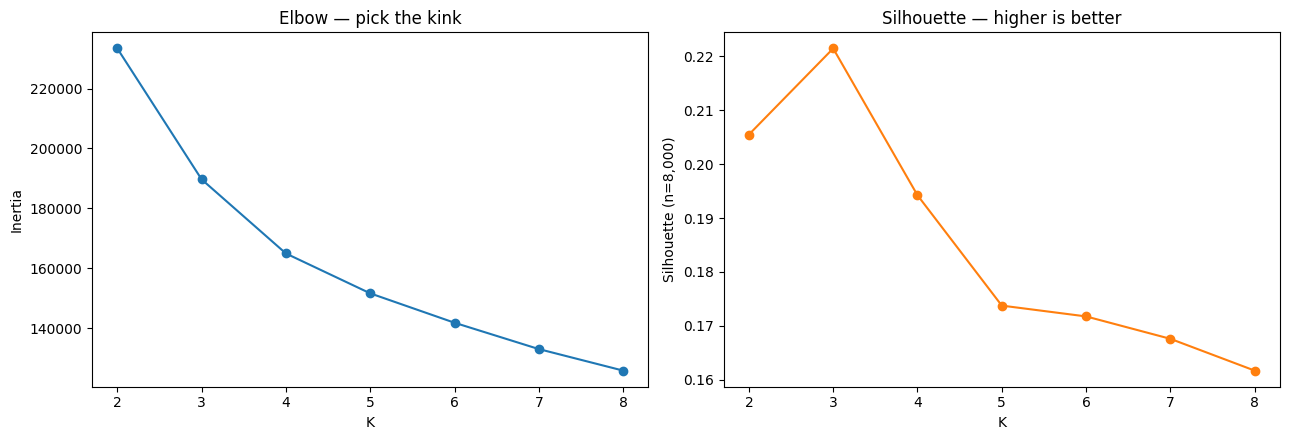

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Reuse Xs from the PCA cell (StandardScaler'd 9 features, NaNs already dropped).
# Silhouette is O(n^2) — sample for the score, but fit K-means on the full data.
SIL_SAMPLE = 8000
sil_rng = np.random.default_rng(0)
sil_idx = sil_rng.choice(len(Xs), size=min(SIL_SAMPLE, len(Xs)), replace=False)

Ks = list(range(2, 9))
inertias, silhouettes = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs)
    labels = km.labels_
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xs[sil_idx], labels[sil_idx]))
    print(f"K={k}: inertia={km.inertia_:,.0f}, silhouette={silhouettes[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(Ks, inertias, 'o-'); ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow — pick the kink')
ax2.plot(Ks, silhouettes, 'o-', color='tab:orange')
ax2.set_xlabel('K'); ax2.set_ylabel(f'Silhouette (n={len(sil_idx):,})')
ax2.set_title('Silhouette — higher is better')
plt.tight_layout(); plt.show()

In [58]:
K = 4
km_final = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Xs)

# Xs was built from df[sop_cols].dropna(), so align labels back via X.index.
defensive_duels['sop_cluster'] = pd.Series(km_final.labels_, index=X.index).reindex(defensive_duels.index)

# Mean of each speed-of-play feature per cluster + cluster size, for naming.
profile = defensive_duels.groupby('sop_cluster')[sop_cols].mean()
profile['count'] = defensive_duels['sop_cluster'].value_counts().reindex(profile.index)
profile['share'] = (profile['count'] / profile['count'].sum()).round(3)
profile.round(3)

C:\Users\zcoch\AppData\Local\Temp\ipykernel_55012\2618548631.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,n_events_30s,delta_x_30s,dist_30s,n_events_60s,delta_x_60s,dist_60s,n_events_ratio_30v60,dist_ratio_30v60,delta_x_diff_30v60,count,share
sop_cluster,,,,,,,,,,,
0.0,0.216,-0.069,3.034,0.270,-0.086,4.193,0.813,0.735,0.017,7565,0.230
1.0,0.442,0.765,6.753,0.392,0.100,6.369,1.140,1.078,0.666,10044,0.305
2.0,0.329,-0.187,5.208,0.193,-0.078,3.096,1.728,1.724,-0.108,5414,0.164
3.0,0.411,-1.494,6.539,0.369,-0.408,6.165,1.125,1.079,-1.086,9891,0.301


- Cluster 0 (23%) — decelerating: lowest 30s activity, ratios ~0.8. Same as before — play cooling down vs. the prior minute.

- Cluster 1 (30.5%) — sustained_forward: high tempo (0.44 events, 6.75 dist), strongly positive delta_x_30s (+0.77) and delta_x_diff (+0.67). Busy and progressing toward goal — sustained attacking phase.

- Cluster 2 (16.4%) — accelerating: middle 30s activity but lowest 60s baseline → ratios ~1.7. Same transition/burst signature as before.

- Cluster 3 (30.1%) — sustained_backward: high tempo (0.41 events, 6.54 dist) but strongly negative delta_x_30s (-1.49) and delta_x_diff (-1.09). Lots happening, but the ball is moving away from the team's attacking end — opponent territorial pressure / forced retreat.

In [59]:
CLUSTER_NAMES = {
    0: 'decelerating',
    1: 'sustained_forward',
    2: 'accelerating',
    3: 'sustained_backward',
}
defensive_duels['sop_cluster_name'] = defensive_duels['sop_cluster'].map(CLUSTER_NAMES)
defensive_duels['sop_cluster_name'].value_counts(dropna=False)

C:\Users\zcoch\AppData\Local\Temp\ipykernel_55012\2482121855.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



sop_cluster_name
sustained_forward     10044
sustained_backward     9891
decelerating           7565
accelerating           5414
NaN                     155
Name: count, dtype: int64

In [60]:
# Sanity check: project the KMeans centroids into the PC space and
# overlay them on the (sampled) PC1/PC2/PC3 scatter, colored by cluster.
import plotly.graph_objects as go
import plotly.colors as pc

K = km_final.n_clusters
centroids_pc = pca.transform(km_final.cluster_centers_)  # (K, 3) in PC space

# Reuse the same sampled indices logic as the PCA cell, but color by cluster.
labels_full = km_final.labels_
sample_n = min(20000, len(Z))
rng = np.random.default_rng(0)
sel = rng.choice(len(Z), size=sample_n, replace=False)

# Pull a qualitative palette and cycle if K exceeds its length.
base_palette = pc.qualitative.Plotly
palette = {k: base_palette[k % len(base_palette)] for k in range(K)}
# Use names if available, else fall back to the integer label.
names = {k: (CLUSTER_NAMES.get(k, f'cluster {k}')
             if 'CLUSTER_NAMES' in globals() else f'cluster {k}')
         for k in range(K)}

fig = go.Figure()
for k in range(K):
    mask = labels_full[sel] == k
    fig.add_trace(go.Scatter3d(
        x=Z[sel][mask, 0], y=Z[sel][mask, 1], z=Z[sel][mask, 2],
        mode='markers',
        marker=dict(size=2, color=palette[k], opacity=0.45),
        name=f'{k}: {names[k]} (n={mask.sum():,})',
    ))

fig.add_trace(go.Scatter3d(
    x=centroids_pc[:, 0], y=centroids_pc[:, 1], z=centroids_pc[:, 2],
    mode='markers+text',
    marker=dict(size=10, color=[palette[k] for k in range(K)],
                line=dict(color='black', width=2), symbol='diamond'),
    text=[names[k] for k in range(K)],
    textposition='top center',
    name='centroids',
    showlegend=False,
))

ev = pca.explained_variance_ratio_
fig.update_layout(
    height=700, width=900,
    title=f'KMeans (K={K}) clusters in PC space, with centroids',
    scene=dict(
        xaxis_title=f'PC1 ({ev[0]:.1%})',
        yaxis_title=f'PC2 ({ev[1]:.1%})',
        zaxis_title=f'PC3 ({ev[2]:.1%})',
    ),
)
fig.show()